In [1]:
# The purpose of this script is to draw graphs to test computed hourly average cloud data_unfiltered
import random
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import glob

# Please change to your own directory
data_dir = "/Users/anora/Team MG Dropbox/Wanru Wu/Energy_Flux" 

In [3]:
# Read the cleaned panel data 
# Compare both filtered (by quality assurance) and unfiltered data
year = 2021

data_u = pd.read_csv(f"{data_dir}/intermediate/grid_with_operation_cloud_{year}_unfiltered.csv")
data_f = pd.read_csv(f"{data_dir}/intermediate/grid_with_operation_cloud_{year}.csv")

In [4]:
# Read the geometry of the grids
grid = gpd.read_file(f"{data_dir}/intermediate/jx_grid.gpkg")
grid

,cell_id,cell_y,cell_x,geometry
0,0_14,0,14,"POLYGON ((236494.173 2710794.886, 236494.173 2..."
1,0_15,0,15,"POLYGON ((241494.173 2710794.886, 241494.173 2..."
2,0_16,0,16,"POLYGON ((246494.173 2710794.886, 246494.173 2..."
3,0_21,0,21,"POLYGON ((271494.173 2710794.886, 271494.173 2..."
4,0_40,0,40,"POLYGON ((366494.173 2710794.886, 366494.173 2..."
...,...,...,...,...
7006,122_62,122,62,"POLYGON ((476494.173 3320794.886, 476494.173 3..."
7007,122_63,122,63,"POLYGON ((481494.173 3320794.886, 481494.173 3..."
7008,123_59,123,59,"POLYGON ((461494.173 3325794.886, 461494.173 3..."
7009,123_60,123,60,"POLYGON ((466494.173 3325794.886, 466494.173 3..."


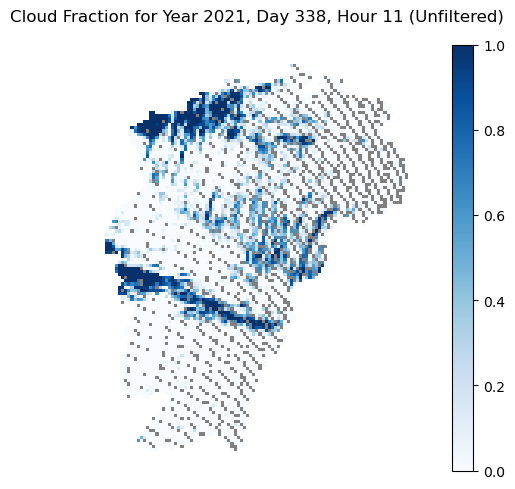

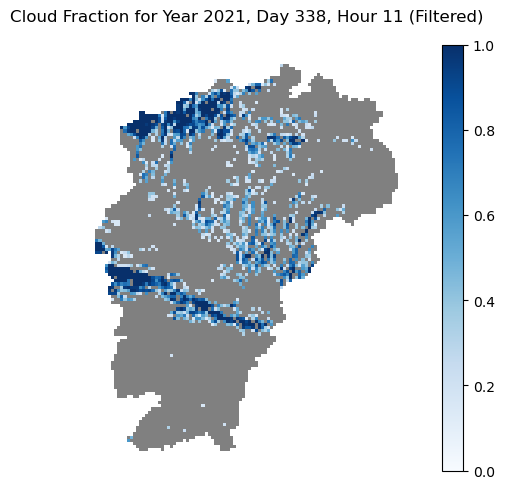

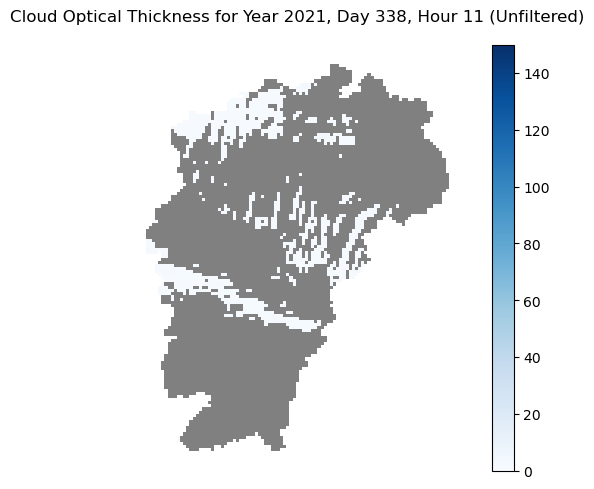

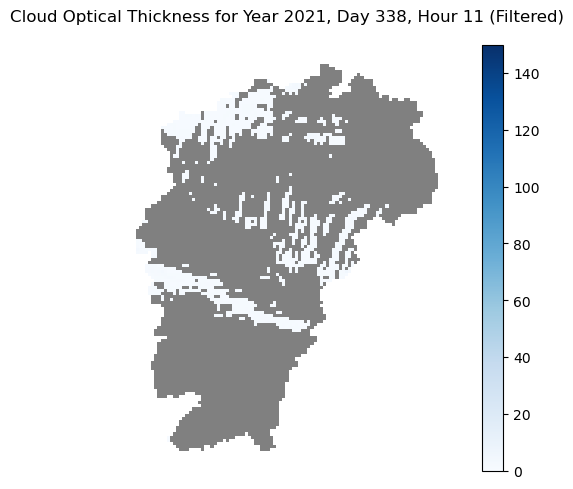

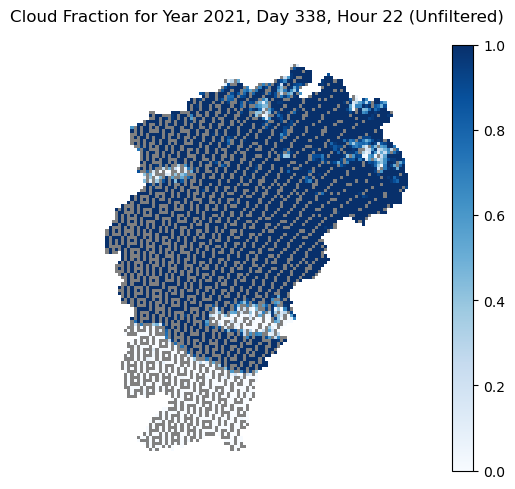

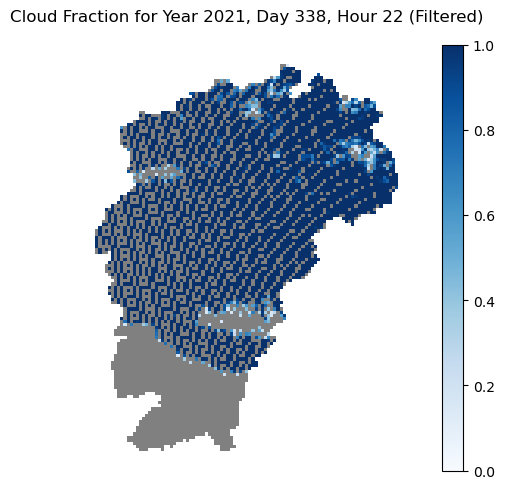

In [21]:
# Pick a random day to investigate
n = random.randint(1, 365)
data_f_day = data_f[data_f['day_of_year'] == n]
data_u_day = data_u[data_u['day_of_year'] == n]

# Plot the data for each hour
for hour in range(0,24):

    ## Convert the hour data to a geopandas object
    # unfiltered
    data_u_day_hour = data_u_day[data_u_day['hour'] == hour]
    plot_data_u = data_u_day_hour.merge(grid, how='left', on='cell_id')
    plot_data_u = gpd.GeoDataFrame(plot_data_u, geometry='geometry')

    # filtered
    data_f_day_hour = data_f_day[data_f_day['hour'] == hour]
    plot_data_f = data_f_day_hour.merge(grid, how='left', on='cell_id')
    plot_data_f = gpd.GeoDataFrame(plot_data_f, geometry='geometry')

    ## Plot cloud fraction
    # Split into NaN and non-NaN
    fraction_nan_mask_u = plot_data_u['cloud_fraction'].isna()
    fraction_nan_mask_f = plot_data_f['cloud_fraction'].isna()

    # Plot cloud fraction plot if there are > 0 solid cells in unfiltered data
    if len(plot_data_u[~fraction_nan_mask_u]) > 0:

        ## Unfiltered cloud fraction graph
        # Set axis
        fig_fraction_u, ax_fraction_u = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_u[fraction_nan_mask_u].plot(ax=ax_fraction_u, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=1)

        # Plot non-NaN cells with a colormap
        plot_data_u[~fraction_nan_mask_u].plot(
            ax=ax_fraction_u,
            column='cloud_fraction',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_fraction_u.set_title(f'Cloud Fraction for Year {year}, Day {n}, Hour {hour} (Unfiltered)')
        ax_fraction_u.set_axis_off()
        plt.tight_layout()
        plt.show()
        plt.close(fig_fraction_u)

        ## Filtered cloud fraction graph
        # Set axis
        fig_fraction_f, ax_fraction_f = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_f[fraction_nan_mask_f].plot(ax=ax_fraction_f, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=1)

        # Plot non-NaN cells with a colormap
        plot_data_f[~fraction_nan_mask_f].plot(
            ax=ax_fraction_f,
            column='cloud_fraction',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_fraction_f.set_title(f'Cloud Fraction for Year {year}, Day {n}, Hour {hour} (Filtered)')
        ax_fraction_f.set_axis_off()
        plt.tight_layout()
        plt.show()
        plt.close(fig_fraction_f)
    
    
    ## Plot cloud optical thickness
    # Split into NaN and non-NaN
    thickness_nan_mask_u = plot_data_u['cloud_optical_thickness'].isna()
    thickness_nan_mask_f = plot_data_f['cloud_optical_thickness'].isna()

    # Plot cloud thickness plot if there are > 0 solid cells in unfiltered data
    if len(plot_data_u[~thickness_nan_mask_u]) > 0:

        ## Unfiltered cloud thickness graph
        # Set axis
        fig_thickness_u, ax_thickness_u = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_u[thickness_nan_mask_u].plot(ax=ax_thickness_u, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=150)

        # Plot non-NaN cells with a colormap
        plot_data_u[~thickness_nan_mask_u].plot(
            ax=ax_thickness_u,
            column='cloud_optical_thickness',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_thickness_u.set_title(f'Cloud Optical Thickness for Year {year}, Day {n}, Hour {hour} (Unfiltered)')
        ax_thickness_u.set_axis_off()
        plt.tight_layout()
        plt.show()
        plt.close(fig_thickness_u)

        ## Filtered cloud thickness graph
        # Set axis
        fig_thickness_f, ax_thickness_f = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_f[thickness_nan_mask_f].plot(ax=ax_thickness_f, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=150)

        # Plot non-NaN cells with a colormap
        plot_data_f[~thickness_nan_mask_f].plot(
            ax=ax_thickness_f,
            column='cloud_optical_thickness',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_thickness_f.set_title(f'Cloud Optical Thickness for Year {year}, Day {n}, Hour {hour} (Filtered)')
        ax_thickness_f.set_axis_off()
        plt.tight_layout()
        plt.show()
        plt.close(fig_thickness_f)


In [2]:
bin_str = '01110110'
start = 0
end = 2
int(bin_str[-(end+1):8-start], 2)

6

In [6]:
### Statistics

#1. In filtered and unfiltered version, how much portion have cloud fraction below 20%
#2. In filtered and unfiltered version, how much overall percent is cloud clear?
#3. In unfiltered version, the overlap between usefulness of cloud optical thickness flag and cloud clear?

# Helper to extract bits from a byte column
def extract_bits(df, column, start, end):
    def _extract(x):
        if pd.isna(x):
            return pd.NA
        bin_str = format(int(x), '08b')
        return int(bin_str[-(end+1):8-start], 2)
    
    return df[column].apply(_extract)

# Read cloud data
modis_dir = f"{data_dir}/intermediate/modis"

all_files = glob.glob(os.path.join(modis_dir, '*.csv'))
for year in range(2020,2023):
    
    files_1km = [f for f in all_files if os.path.basename(f).startswith(f'1km_{year}')]
    files_5km = [f for f in all_files if os.path.basename(f).startswith(f'5km_{year}')]
    df_1km = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(files_1km)], ignore_index=True)
    df_5km = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(files_5km)], ignore_index=True)

    # Convert to numerical data and handle NaN
    byte_cols = [col for col in df_1km.columns if col.startswith('qa1_byte_')]
    for col in byte_cols:
        df_1km[col] = pd.to_numeric(df_1km[col], errors='coerce')


    ##### Unfiltered Version
    # In unfiltered data, how much portion have cloud fraction below 20%
    df_5km_t = df_5km[~pd.isna(df_5km['cloud_fraction'])].copy()
    df_5km_fraction_l20 = df_5km_t[df_5km_t['cloud_fraction']<0.2].copy()
    df_5km_fraction_l20_portion = len(df_5km_fraction_l20)/len(df_5km_t)
    print(f"In {year}, in unfiltered data, {df_5km_fraction_l20_portion} percent of cloud fraction is below 20%")

    # In unfiltered data, how much overall percent is cloud clear?
    df_1km_t = df_1km.copy()
    df_1km_t['retrival_phase_flag'] = extract_bits(df_1km_t, 'qa1_byte_2', 0, 2)           # Byte 2, Bit 0-2
    df_1km_t = df_1km_t[df_1km_t['retrival_phase_flag']!=0]
    df_1km_t = df_1km_t[~pd.isna(df_1km_t['retrival_phase_flag'])]
    df_1km_clear = df_1km_t[df_1km_t['retrival_phase_flag']==1]
    df_1km_clear_portion = len(df_1km_clear)/len(df_1km_t)
    print(f"In {year}, in unfiltered data, {df_1km_clear_portion} percent of cloud is clear")

    #In unfiltered version, how much of the clear cloud is marked as useful 
    df_1km_clear['usefulness_flag'] = extract_bits(df_1km_clear, 'qa1_byte_0', 0, 0) # Byte 0, Bit 0
    df_1km_clear_useful = df_1km_clear[df_1km_clear['usefulness_flag']==1]
    df_1km_clear_useful_portion = len(df_1km_clear_useful)/len(df_1km_clear)
    print(f"In {year}, in unfiltered data, {df_1km_clear_useful_portion} percent of clear cloud is useful")




    ##### Filtered Version

    # Filter out invalid data points based on quality assurance indicator
    
    ### 1KM DATA

    # Extract all flags
    df_1km['usefulness_flag'] = extract_bits(df_1km, 'qa1_byte_0', 0, 0)           # Byte 0, Bit 0

    # Apply base mask — Usefulness Flag == 1
    base_mask = df_1km['usefulness_flag'] == 1
    df_1km_filtered = df_1km[base_mask].copy()

    ### 5KM DATA

    # Filter out invalid data points based on quality assurance indicator
    # Convert to numerical data and handle NaN
    byte_cols = [col for col in df_5km.columns if col.startswith('qa5_byte_')]
    for col in byte_cols:
        df_5km[col] = pd.to_numeric(df_5km[col], errors='coerce')

    # Extract all flags
    df_5km['usefulness_flag'] = extract_bits(df_5km, 'qa5_byte_1', 0, 0)           # Byte 1, Bit 0

    # Apply base mask — Usefulness Flag == 1
    base_mask = df_5km['usefulness_flag'] == 1
    df_5km_filtered = df_5km[base_mask].copy()

    # In filtered data, how much portion have cloud fraction below 20%
    df_5km_filtered_t = df_5km_filtered[~pd.isna(df_5km_filtered['cloud_fraction'])].copy()
    df_5km_filtered_fraction_l20 = df_5km_filtered_t[df_5km_filtered_t['cloud_fraction']<0.2].copy()
    df_5km_filtered_fraction_l20_portion = len(df_5km_filtered_fraction_l20)/len(df_5km_filtered_t)
    print(f"In {year}, in filtered data, {df_5km_filtered_fraction_l20_portion} percent of cloud fraction is below 20%")

    # In filtered data, how much overall percent is cloud clear?
    df_1km_filtered_t = df_1km_filtered.copy()
    df_1km_filtered_t['retrival_phase_flag'] = extract_bits(df_1km_filtered_t, 'qa1_byte_2', 0, 2)           # Byte 2, Bit 0-2
    df_1km_filtered_t = df_1km_filtered_t[df_1km_filtered_t['retrival_phase_flag']!=0]
    df_1km_filtered_t = df_1km_filtered_t[~pd.isna(df_1km_filtered_t['retrival_phase_flag'])]
    df_1km_filtered_clear = df_1km_filtered_t[df_1km_filtered_t['retrival_phase_flag']==1]
    df_1km_filtered_clear_portion = len(df_1km_filtered_clear)/len(df_1km_filtered_t)
    print(f"In {year}, in filtered data, {df_1km_filtered_clear_portion} percent of cloud is clear")




  
    



In 2020, in unfiltered data, 0.18923783664374685 percent of cloud fraction is below 20%
In 2020, in unfiltered data, 0.23940195438844977 percent of cloud is clear
In 2020, in unfiltered data, 0.23940195438844977 percent of clear cloud is useful
In 2020, in filtered data, 0.01701430730355348 percent of cloud fraction is below 20%
In 2020, in filtered data, 0.0 percent of cloud is clear


KeyboardInterrupt: 